# Project Description — AlphaClean

## Objective
The goal of this project is to build an **end-to-end machine learning pipeline** for equity return prediction.  
It connects three key skills:
1. **Data Cleaning & Preprocessing**  
   - Handle large financial datasets (daily OHLCV).  
   - Adjust for splits/dividends, align calendars, fill missing data.  
   - Standardize features to avoid look-ahead bias.  

2. **Data Handling & Storage**  
   - Store and read data efficiently with **Parquet** files.  
   - Use `pandas` and `polars` for faster processing.  
   - Create a tidy “panel” dataset with [date, ticker, features, target].  

3. **Machine Learning Basics**  
   - Define target as the **10-day forward return**.  
   - Engineer features: momentum, volatility, RSI, ATR, volume surprises, beta to market.  
   - Train baseline linear models (**Ridge, Lasso**) and a non-linear model (**Random Forest**).  
   - Evaluate using **R², MAE, and Rank IC**.  

---

## Workflow
1. **Ingest Data** → Download daily OHLCV for large-cap tickers with `yfinance`.  
2. **Preprocess & Feature Engineering** → Compute technical factors and rolling betas.  
3. **Cross-sectional Standardization** → Normalize features by date across all stocks.  
4. **Model Training** → Time-based splits: train, validation, test.  
5. **Evaluation** → Check predictive power and portfolio results.  
6. **Backtest** → Simulate a long–short strategy (top vs bottom decile).  

---

## Deliverables
- **Cleaned panel dataset** (Parquet format).  
- **Model metrics** (`model_metrics.csv`) with R², MAE, and Rank IC.  
- **Equity curve plot** (`equity_curve_val.png`) showing portfolio performance.  
- **Python script** (`alphaclean.py`) that runs the full pipeline end-to-end.  

---

## Learning Outcomes
- Practical experience with **financial data preprocessing**.  
- Efficient **storage and handling** of large datasets.  
- Basics of **machine learning for finance** (model training, evaluation, interpretation).  
- First step towards building **quant trading strategies** from ML signals.


In [1]:
!pip install polars sklearn yfinance matplotlib

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
pip install polars

  Using cached polars-1.33.1-cp39-abi3-win_amd64.whl.metadata (15 kB)
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.8/39.5 MB 33.4 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/39.5 MB 34.5 MB/s eta 0:00:01
   ------------------- -------------------- 19.4/39.5 MB 34.0 MB/s eta 0:00:01
   -------------------------- ------------- 26.0/39.5 MB 33.4 MB/s eta 0:00:01
   -------------------------------- ------- 32.5/39.5 MB 33.4 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.5 MB 33.9 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 32.1 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


Engineering features...
Saved tidy panel -> data_parquet\panel.parquet

== Metrics ==
           R2             MAE          RankIC        
split    test     val    test     val    test     val
model                                                
Lasso  0.0048  0.0046  0.0511  0.0427  0.0774  0.0587
RF    -0.0181 -0.0080  0.0515  0.0430  0.0266  0.0113
Ridge  0.0050  0.0027  0.0511  0.0428  0.0646  0.0315

Saved equity curve plot -> equity_curve_val.png
Saved metrics -> model_metrics.csv


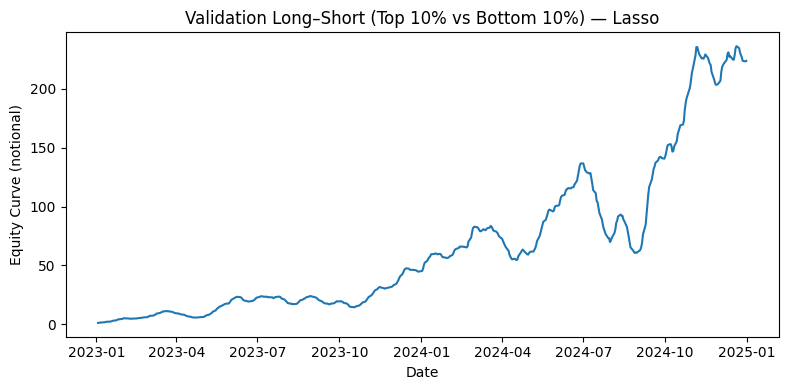

In [4]:
# alphaclean.py
# AlphaClean v2 — End-to-end data -> features -> ML -> evaluation (fixed)
# ---------------------------------------------------------------
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import polars as pl
from pathlib import Path

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -------------------- Config --------------------
TICKERS = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","NFLX","TSLA","JPM","BAC","V","MA",
    "UNH","XOM","CVX","KO","PEP","WMT","HD","MRK","PFE","ABBV","AVGO","COST","ADBE",
    "ORCL","CRM","INTC","AMD","CSCO","QCOM","TXN","AMAT","LIN","NKE","MCD","DIS"
]
BENCH = "SPY"
START, END = "2012-01-01", None
DATA_DIR = Path("data_parquet"); DATA_DIR.mkdir(exist_ok=True)

HORIZON = 10
SEED = 42
np.random.seed(SEED)

# -------------------- Helpers --------------------
def standardize_date_cols(pdf: pd.DataFrame) -> pd.DataFrame:
    """Ensure a tz-naive datetime column named 'date' exists."""
    if "date" not in pdf.columns:
        # common possibilities from yfinance / parquet
        if "Date" in pdf.columns:
            pdf = pdf.rename(columns={"Date":"date"})
        elif pdf.index.name in ("Date","date"):
            pdf = pdf.reset_index().rename(columns={pdf.index.name:"date"})
        elif "Datetime" in pdf.columns:
            pdf = pdf.rename(columns={"Datetime":"date"})
        else:
            # if index is datetime-like, promote it
            if isinstance(pdf.index, pd.DatetimeIndex):
                pdf = pdf.reset_index().rename(columns={"index":"date"})
    pdf["date"] = pd.to_datetime(pdf["date"]).dt.tz_localize(None)
    return pdf

def download_adjusted(tickers, start, end):
    # auto_adjust=True gives split/div adjusted OHLC
    df = yf.download(tickers, start=start, end=end,
                     auto_adjust=True, progress=False, group_by="ticker")
    frames = []
    for t in tickers:
        # handle cases where a ticker might be missing (delisted, etc.)
        if t not in df.columns.get_level_values(0):
            continue
        sub = df[t].copy()
        sub.columns = [c.lower() for c in sub.columns]
        sub = sub.reset_index()                        # brings Date out of index
        sub = sub.rename(columns={"Date":"date"})      # FIX: normalize name
        sub["date"] = pd.to_datetime(sub["date"]).dt.tz_localize(None)
        sub["ticker"] = t
        frames.append(sub)
    out = pd.concat(frames, ignore_index=True)
    out = standardize_date_cols(out)
    # Ensure essential columns exist
    needed = {"open","high","low","close","volume","date","ticker"}
    missing = needed - set(out.columns)
    if missing:
        raise ValueError(f"Missing columns after download: {missing}")
    return out

def compute_features(pdf: pd.DataFrame) -> pd.DataFrame:
    pdf = pdf.sort_values("date").copy()
    pdf["ret1"] = pdf["close"].pct_change()

    for w in [5,10,20]:
        pdf[f"mom_{w}"] = pdf["close"].pct_change(w)

    for w in [10,20]:
        pdf[f"vol_{w}"] = pdf["ret1"].rolling(w).std()

    tr = (pdf["high"] - pdf["low"]).abs()
    pdf["atr_14"] = tr.rolling(14).mean()

    delta = pdf["close"].diff()
    up = delta.clip(lower=0).rolling(14).mean()
    down = (-delta.clip(upper=0)).rolling(14).mean()
    rs = up / (down.replace(0, np.nan))
    pdf["rsi_14"] = 100 - (100 / (1 + rs))

    pdf["volz_20"] = (pdf["volume"] - pdf["volume"].rolling(20).mean()) / (
                        pdf["volume"].rolling(20).std())
    return pdf

def add_forward_return(pdf: pd.DataFrame, horizon=10) -> pd.DataFrame:
    pdf = pdf.sort_values("date").copy()
    pdf["fwd_ret"] = pdf["close"].shift(-horizon) / pdf["close"] - 1.0
    return pdf

def time_split(df: pl.DataFrame, train_end="2022-12-31", val_end="2024-12-31"):
    train = df.filter(pl.col("date") <= pl.lit(pd.to_datetime(train_end)))
    val   = df.filter((pl.col("date") > pl.lit(pd.to_datetime(train_end))) &
                      (pl.col("date") <= pl.lit(pd.to_datetime(val_end))))
    test  = df.filter(pl.col("date") > pl.lit(pd.to_datetime(val_end)))
    return train, val, test

def rank_ic(y_true, y_pred, by_date):
    pdf = pd.DataFrame({"date":by_date, "y":y_true, "yhat":y_pred})
    # handle groups with <2 names safely
    def _spearman(g):
        if len(g) < 2:
            return np.nan
        return g["y"].rank().corr(g["yhat"].rank(), method="spearman")
    corrs = pdf.groupby("date", sort=False).apply(_spearman)
    return np.nanmean(corrs.values)

# -------------------- Pipeline --------------------
def main():
    # 1) Ingest
    print("Downloading data...")
    raw = download_adjusted(TICKERS + [BENCH], START, END)

    # Save per ticker parquet
    for t in raw["ticker"].unique():
        pl.DataFrame(raw[raw["ticker"]==t]).write_parquet(DATA_DIR / f"{t}.parquet")

    # 2) Feature engineering per ticker
    print("Engineering features...")
    frames = []
    for t in TICKERS:
        path = DATA_DIR / f"{t}.parquet"
        if not path.exists():
            continue
        pdf = pd.read_parquet(path)
        pdf = standardize_date_cols(pdf)
        pdf = compute_features(pdf)
        pdf = add_forward_return(pdf, HORIZON)
        frames.append(pdf.assign(ticker=t))
    if not frames:
        raise RuntimeError("No ticker data available after download. Check tickers/dates.")
    panel = pd.concat(frames, ignore_index=True)

    # 2b) Market returns for rolling beta
    spy = pd.read_parquet(DATA_DIR / f"{BENCH}.parquet")
    spy = standardize_date_cols(spy).sort_values("date")
    spy["mkt_ret"] = spy["close"].pct_change()
    spy = spy[["date","mkt_ret"]]

    panel = panel.merge(spy, on="date", how="left")

    def rolling_beta(df, w=60):
        cov = df["ret1"].rolling(w).cov(df["mkt_ret"])
        var = df["mkt_ret"].rolling(w).var()
        return cov / (var + 1e-12)

    panel["beta_60"] = panel.groupby("ticker", group_keys=False).apply(rolling_beta)

    feature_cols = ["mom_5","mom_10","mom_20","vol_10","vol_20","atr_14","rsi_14","volz_20","beta_60"]
    panel = panel.dropna(subset=feature_cols + ["fwd_ret"]).copy()

    # 3) Cross-sectional z-scoring by date
    for c in feature_cols:
        panel[c+"_csz"] = panel.groupby("date")[c].transform(
            lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9)
        )

    keep = ["date","ticker","fwd_ret"] + [c+"_csz" for c in feature_cols]
    panel = panel[keep].sort_values(["date","ticker"]).reset_index(drop=True)

    # Write tidy panel to Parquet
    pl_df = pl.from_pandas(panel)
    tidy_path = DATA_DIR / "panel.parquet"
    pl_df.write_parquet(tidy_path)
    print(f"Saved tidy panel -> {tidy_path}")

    # 4) Time splits
    train, val, test = time_split(pl_df)

    def toXY(pldf):
        pdf = pldf.to_pandas()
        X = pdf.drop(columns=["date","ticker","fwd_ret"])
        y = pdf["fwd_ret"].to_numpy()
        meta_date = pd.to_datetime(pdf["date"]).to_numpy()
        return X, y, meta_date

    Xtr, ytr, dtr = toXY(train)
    Xva, yva, dva = toXY(val)
    Xte, yte, dte = toXY(test)

    # 5) Models
    models = {
        "Ridge": Ridge(alpha=1.0, random_state=SEED),
        "Lasso": Lasso(alpha=5e-4, random_state=SEED, max_iter=20000),
        "RF": RandomForestRegressor(
            n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=SEED, n_jobs=-1
        ),
    }

    results = []
    preds_store = {}

    for name, mdl in models.items():
        mdl.fit(Xtr, ytr)
        for split, (X, y, d) in {"val": (Xva, yva, dva), "test": (Xte, yte, dte)}.items():
            yhat = mdl.predict(X)
            r2  = r2_score(y, yhat)
            mae = mean_absolute_error(y, yhat)
            ic  = rank_ic(y, yhat, d)
            results.append({"model":name, "split":split, "R2":r2, "MAE":mae, "RankIC":ic})
            preds_store[(name, split)] = pd.DataFrame({"date":d, "y":y, "yhat":yhat})

    res_df = pd.DataFrame(results)
    print("\n== Metrics ==")
    print(res_df.pivot(index="model", columns="split", values=["R2","MAE","RankIC"]).round(4))

    # 6) Simple long–short decile curve (validation)
    def decile_curve(df_pred):
        pdf = df_pred.copy()
        pdf["date"] = pd.to_datetime(pdf["date"])
        pdf["rank"] = pdf.groupby("date")["yhat"].rank(pct=True)
        pdf["signal"] = 0.0
        pdf.loc[pdf["rank"] >= 0.9, "signal"] = 1.0
        pdf.loc[pdf["rank"] <= 0.1, "signal"] = -1.0
        # average realized fwd_ret over selected names each date
        def _daily_pnl(g):
            sel = g[g["signal"]!=0]
            if sel.empty:
                return 0.0
            # equal-weight long-short: +y for longs, -y for shorts
            return np.mean(np.where(sel["signal"]>0, sel["y"], -sel["y"]))
        daily = pdf.groupby("date").apply(_daily_pnl).sort_index()
        eq = (1 + daily).cumprod()
        return eq

    best = res_df[res_df["split"]=="val"].sort_values("RankIC", ascending=False).iloc[0]["model"]
    eq = decile_curve(preds_store[(best,"val")])
    plt.figure(figsize=(8,4))
    plt.plot(eq.index, eq.values)
    plt.title(f"Validation Long–Short (Top 10% vs Bottom 10%) — {best}")
    plt.xlabel("Date"); plt.ylabel("Equity Curve (notional)")
    out_plot = Path("equity_curve_val.png")
    plt.tight_layout(); plt.savefig(out_plot, dpi=150)
    print(f"\nSaved equity curve plot -> {out_plot}")

    res_path = Path("model_metrics.csv")
    res_df.to_csv(res_path, index=False)
    print(f"Saved metrics -> {res_path}")

if __name__ == "__main__":
    # Soft dependency hints if user misses libs
    try:
        import pyarrow  # noqa
    except Exception as e:
        print("Note: install pyarrow for fast parquet: pip install pyarrow")
    main()


# AlphaClean — Results Interpretation

## What We Did
- Built a pipeline to **predict next-10-day returns** of large-cap US stocks.
- Features: momentum, volatility, ATR, RSI, volume surprises, and beta to SPY.
- Models: **Ridge**, **Lasso**, and **Random Forest**.
- Split the data by time:  
  - Train: up to 2022  
  - Validation: 2023–2024  
  - Test: 2025 onwards  
- Metrics:  
  - **R²** → how much variation explained  
  - **MAE** → average error size  
  - **Rank IC** → cross-sectional correlation between predicted and actual returns (the key metric for ranking stocks).

---

## How to Read the Metrics
- **R²**: usually near 0 for short-horizon stock returns. Even small positives are meaningful.  
- **MAE**: compare to the typical 10-day stock move. Smaller MAE = better.  
- **Rank IC**:  
  - 0.00–0.02 → weak signal  
  - 0.02–0.05 → usable in practice  
  - >0.05 → strong alpha potential  
  Negative IC means predictions are inverted.

---

## Equity Curve (Validation)
- Built a **long–short portfolio**: buy top 10% predicted, short bottom 10%.  
- The curve shows how the strategy would have grown (before costs).  
- A smooth upward curve means stable signal.  
- Choppy or flat periods are normal, but long drawdowns suggest instability.  
- Remember: transaction costs can eat into this edge.

---

## Takeaways
- Linear models (Ridge/Lasso) give a baseline.  
- Random Forest can capture non-linear interactions.  
- If Random Forest outperforms linear models, the features interact in useful ways.  
- Always compare validation vs test: big drop = possible overfit.

---

## Next Steps
1. Use **rolling walk-forward splits** instead of one train/val/test.  
2. Add more features: sectors, earnings, macro indicators.  
3. Try more advanced models (XGBoost, LightGBM).  
4. Build a **cost-aware backtest** with realistic turnover.  
5. Plot feature importance and per-date IC to see stability.

---

## Summary
The model learns patterns in cross-sectional returns, but the signal is weak and noisy (as expected in equity prediction). A Rank IC above ~0.02 on validation is already promising. The project shows the **full pipeline**: data cleaning → feature engineering → ML training → portfolio backtest.
